In [1]:
pip install torch transformers


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
path = "sp500_headlines_2008_2024.csv"
headline_df = pd.read_csv(path).drop(columns=["CP"])
headline_df["aligned_date"] = pd.to_datetime(headline_df["Date"]) + pd.offsets.MonthBegin(1)
headline_df.sort_values("Date", inplace=True)
headline_df.head(20)

,Title,Date,aligned_date
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,2008-02-01
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,2008-02-01
2,2008 predictions for the S&P 500,2008-01-02,2008-02-01
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,2008-02-01
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,2008-02-01
5,How Investing in Intangibles -- Like Employee ...,2008-01-09,2008-02-01
6,Head And Shoulders Top Bodes Ill For Bulls,2008-01-09,2008-02-01
7,U.S. Stocks Zigzag Higher As Bernanke Speech S...,2008-01-10,2008-02-01
8,It's a Black Monday as stock markets tank in e...,2008-01-22,2008-02-01
9,U.S. Stocks Largely Recover From Early Plunge,2008-01-22,2008-02-01


In [4]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="ProsusAI/finbert")

/Users/pierson.chu/Downloads/github/recession_lookback/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 50515.62it/s]


In [5]:
headlines = headline_df["Title"].tolist()
classification = classifier(headlines, top_k=None)

In [6]:
pos_scores = []
neg_scores = []
neu_scores = []

for results in classification:
    score_dict = {result["label"]: result["score"] for result in results}
    pos_scores.append(score_dict.get("positive", 0))
    neg_scores.append(score_dict.get("negative", 0))
    neu_scores.append(score_dict.get("neutral", 0))

headline_df["Pos_Score"] = pos_scores
headline_df["Neg_Score"] = neg_scores
headline_df["Neu_Score"] = neu_scores

output_path = "sp500_headlines_2008_2024_with_sentiment.csv"
headline_df.to_csv(output_path, index=False)
headline_df.head(20)

,Title,Date,aligned_date,Pos_Score,Neg_Score,Neu_Score
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,2008-02-01,0.188399,0.604176,0.207425
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,2008-02-01,0.011426,0.962149,0.026425
2,2008 predictions for the S&P 500,2008-01-02,2008-02-01,0.052938,0.122815,0.824247
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,2008-02-01,0.861627,0.064192,0.074181
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,2008-02-01,0.586567,0.165055,0.248378
5,How Investing in Intangibles -- Like Employee ...,2008-01-09,2008-02-01,0.082773,0.014693,0.902534
6,Head And Shoulders Top Bodes Ill For Bulls,2008-01-09,2008-02-01,0.024102,0.843392,0.132506
7,U.S. Stocks Zigzag Higher As Bernanke Speech S...,2008-01-10,2008-02-01,0.542340,0.282442,0.175218
8,It's a Black Monday as stock markets tank in e...,2008-01-22,2008-02-01,0.025481,0.926721,0.047798
9,U.S. Stocks Largely Recover From Early Plunge,2008-01-22,2008-02-01,0.446016,0.516208,0.037776


In [10]:
headline_df = pd.read_csv("sp500_headlines_2008_2024_with_sentiment.csv", 
    parse_dates=["Date","aligned_date"])
headline_df.head(20)

,Title,Date,aligned_date,Pos_Score,Neg_Score,Neu_Score
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,2008-02-01,0.188399,0.604176,0.207425
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,2008-02-01,0.011426,0.962149,0.026425
2,2008 predictions for the S&P 500,2008-01-02,2008-02-01,0.052938,0.122815,0.824247
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,2008-02-01,0.861627,0.064192,0.074181
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,2008-02-01,0.586567,0.165055,0.248378
5,How Investing in Intangibles -- Like Employee ...,2008-01-09,2008-02-01,0.082773,0.014693,0.902534
6,Head And Shoulders Top Bodes Ill For Bulls,2008-01-09,2008-02-01,0.024102,0.843392,0.132506
7,U.S. Stocks Zigzag Higher As Bernanke Speech S...,2008-01-10,2008-02-01,0.542340,0.282442,0.175218
8,It's a Black Monday as stock markets tank in e...,2008-01-22,2008-02-01,0.025481,0.926721,0.047798
9,U.S. Stocks Largely Recover From Early Plunge,2008-01-22,2008-02-01,0.446016,0.516208,0.037776


In [11]:
mean_sentiment = headline_df.groupby(["Date", "aligned_date"])[["Pos_Score", "Neg_Score", "Neu_Score"]].mean().reset_index()

We will aggregate these daily scores into a rolling 30-day sentiment index using an Exponential Moving Average (EMA) and create a "Neutrality Ratio" to cut through the noise of neutral financial journalism.
- The Neutrality Ratio Filter: Financial headlines often state dry facts, causing FinBERT to output high "Neutral" probabilities. We have to filter this to show only directional bias.
    - By calculating `Positive / (Positive + Negative)`, it isolates the directional bias by answering the question: Of the sentiment that actually took a stance, how much of it was positive?
- EMA: Markets react to recent news much more violently than month-old news, so we use an EMA rather than an SMA to look at the score

In [12]:
mean_sentiment["Neutrality_Ratio"]= (mean_sentiment["Pos_Score"]/(mean_sentiment["Pos_Score"]+mean_sentiment["Neg_Score"])).fillna(0.5)
mean_sentiment["Pos_Score_30day_EMA"] = mean_sentiment["Pos_Score"].ewm(span=30, adjust=False).mean()
mean_sentiment["Neg_Score_30day_EMA"] = mean_sentiment["Neg_Score"].ewm(span=30, adjust=False).mean()
mean_sentiment["Neutrality_Ratio_30day_EMA"] = mean_sentiment["Neutrality_Ratio"].ewm(span=30, adjust=False).mean()
mean_sentiment.head(20)


,Date,aligned_date,Pos_Score,Neg_Score,Neu_Score,Neutrality_Ratio,Pos_Score_30day_EMA,Neg_Score_30day_EMA,Neutrality_Ratio_30day_EMA
0,2008-01-02,2008-02-01,0.084255,0.563047,0.352699,0.130163,0.084255,0.563047,0.130163
1,2008-01-03,2008-02-01,0.861627,0.064192,0.074181,0.930664,0.134408,0.530862,0.181808
2,2008-01-07,2008-02-01,0.586567,0.165055,0.248378,0.780401,0.163579,0.507262,0.220427
3,2008-01-09,2008-02-01,0.053438,0.429042,0.517520,0.110756,0.156473,0.502216,0.213351
4,2008-01-10,2008-02-01,0.542340,0.282442,0.175218,0.657556,0.181368,0.488037,0.242010
5,2008-01-22,2008-02-01,0.126644,0.619509,0.253847,0.169730,0.177837,0.496519,0.237347
6,2008-01-29,2008-02-01,0.043178,0.766623,0.190199,0.053319,0.169150,0.513945,0.225474
7,2008-01-30,2008-02-01,0.096287,0.016126,0.887587,0.856544,0.164449,0.481827,0.266188
8,2008-02-01,2008-03-01,0.086783,0.020854,0.892363,0.806258,0.159438,0.452087,0.301031
9,2008-02-05,2008-03-01,0.075444,0.452884,0.471671,0.142798,0.154019,0.452139,0.290823


In [13]:
from fredapi import Fred
from dotenv import load_dotenv
import os
load_dotenv()
FRED_API_KEY = os.getenv("FRED_API_KEY")
fred_auth = fred = Fred(api_key=FRED_API_KEY)
recession_data = pd.DataFrame(fred_auth.get_series("USREC")).reset_index().rename(columns={"index": "aligned_date", 0: "recession"})
recession_data = recession_data[recession_data['aligned_date'] >= pd.to_datetime('2001-01-01')]
recession_data["period_rolling_recession"]= recession_data["recession"].rolling(window=6, min_periods=1).max().shift(-6)
recession_data[["aligned_date","period_rolling_recession"]].dropna()

,aligned_date,period_rolling_recession
1753,2001-01-01,1.0
1754,2001-02-01,1.0
1755,2001-03-01,1.0
1756,2001-04-01,1.0
1757,2001-05-01,1.0
...,...,...
2046,2025-06-01,0.0
2047,2025-07-01,0.0
2048,2025-08-01,0.0
2049,2025-09-01,0.0


In [31]:

feature_data = pd.merge(
    mean_sentiment, 
    recession_data[["aligned_date","period_rolling_recession"]].dropna(), 
    on='aligned_date', 
    how='left'
)
feature_data.drop(columns=["Date","Pos_Score","Neg_Score","Neu_Score","Neutrality_Ratio"], inplace= True)
feature_data = feature_data.dropna()
feature_data.dropna()
output_path = "sentiment_training_data_features.csv"
feature_data.to_csv(output_path, index=False)

At this point we've running into an issue: The Mismatched History Problem. There is a different period of data sets that is available to us.

The "Test Set" Golden Rule
- In a head-to-head evaluation or an ensemble, the models are competing to see how they handle "unseen" data. 
- We have to make sure they test on the same unseen data to ensure a fair test.

To tackle this: 
- Macro Model: Trained on 2001–2015. Tested on 2016–Present.
- Sentiment Model: Train on 2008–2015. Test on 2016–Present.

In [15]:
pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
phase_1_split_aligned_date = "2016-07-01"
training_data = feature_data[feature_data["aligned_date"]<phase_1_split_aligned_date] 
testing_data = feature_data[feature_data["aligned_date"]>=phase_1_split_aligned_date]
training_x = training_data.drop(columns=['period_rolling_recession','aligned_date'])
training_y = training_data['period_rolling_recession']
testing_x = testing_data.drop(columns=['period_rolling_recession','aligned_date'])
testing_y = testing_data['period_rolling_recession']

ratio = (training_y == 0).sum() / (training_y == 1).sum()
print(f"Calculated scale_pos_weight: {ratio:.2f}")

Calculated scale_pos_weight: 11.11


In [17]:
lightgbm_model = LGBMClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

In [18]:
# mac conflict
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [19]:
lightgbm_model.fit(training_x, training_y)
y_lightgbm_pred = lightgbm_model.predict(testing_x)

[LightGBM] [Info] Number of positive: 133, number of negative: 1478
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 1611, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.082557 -> initscore=-2.408096
[LightGBM] [Info] Start training from score -2.408096
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [21]:
print("\nClassification Report for LightGBM:")
print(classification_report(testing_y, y_lightgbm_pred))


Classification Report for LightGBM:
              precision    recall  f1-score   support

         0.0       0.90      0.79      0.84      1751
         1.0       0.00      0.00      0.00       145

    accuracy                           0.73      1896
   macro avg       0.45      0.39      0.42      1896
weighted avg       0.84      0.73      0.78      1896



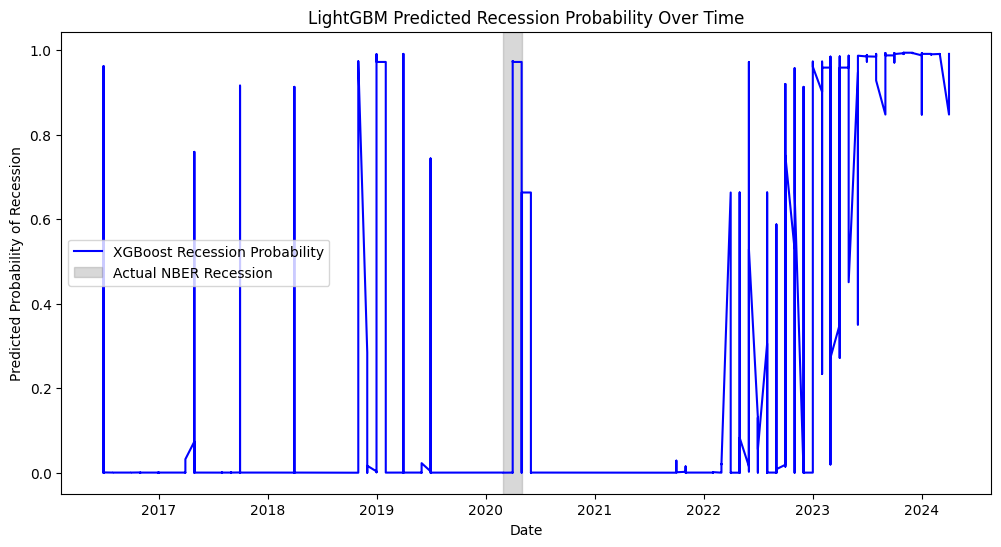

In [29]:
y_lightgbm_probs_all = lightgbm_model.predict_proba(testing_x)
y_recession_probs = y_lightgbm_probs_all [:, 1]
lightgbm_proba_table = testing_data[['aligned_date']].copy()
lightgbm_proba_table['y_recession_prob'] = y_recession_probs
lightgbm_proba_table = pd.merge(
    lightgbm_proba_table, 
    recession_data, 
    on='aligned_date', 
    how='left'
)

lightgbm_proba_table['change'] = lightgbm_proba_table['recession'].diff()
starts = lightgbm_proba_table[lightgbm_proba_table['change'] == 1]['aligned_date'].tolist()
ends = lightgbm_proba_table[lightgbm_proba_table['change'] == -1]['aligned_date'].tolist()
if lightgbm_proba_table['recession'].iloc[0] == 1:
    starts.insert(0, lightgbm_proba_table['aligned_date'].iloc[0])
if lightgbm_proba_table['recession'].iloc[-1] == 1:
    ends.append(lightgbm_proba_table['aligned_date'].iloc[-1])
    
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))

# 2. Plot the probability line
plt.plot(lightgbm_proba_table['aligned_date'], lightgbm_proba_table['y_recession_prob'], 
         label='XGBoost Recession Probability', color='blue')

for s, e in zip(starts, ends):
    plt.axvspan(s, e, color='gray', alpha=0.3, label='Actual NBER Recession')
plt.title('LightGBM Predicted Recession Probability Over Time')
plt.xlabel('Date')
plt.ylabel('Predicted Probability of Recession')
plt.legend()

In [30]:
lightgbm_proba_table.head(20)
auc = roc_auc_score(testing_y, lightgbm_proba_table["y_recession_prob"])
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.2864


A score below 0.2864 means my model is consistently predicting the opposite of what is actually happening. It is assigning lower risk scores to actual recession months than it is to normal months. We can look back at the factors we've mentioned:
- The Peak Bubble: Financial news is often most euphoric right before a crash.
- The "Bad News is Good News" Paradox: As noted in your project spec, bad macro data often generates positive headlines because the market expects Fed rate cuts.
- The Lagging Echo Chamber: The media might not predict crashes; they might only report on them after they happen.